In [1]:
MODEL_DATASET = {
    'qwen-0.5b': 'output/results_probeonly_20260527_154159_qwen-0.5b.json',
    'llama-1b': 'output/results_probeonly_20260520_154434_llama-1b.json',
    'gemma-27b': 'output/20260508-runpod/results_probeonly_20260508_171344_gemma-27b.json',
    'qwen-32b': 'output/20260508-runpod/results_probeonly_20260508_184340_qwen-32b.json',
    'qwq-32b': 'output/20260508-runpod/results_probeonly_20260508_193619_qwq-32b.json',
    'llama-70b': 'output/20260511-runpod/results_probeonly_20260511_195030_llama-70b.json',
    'qwen-72b': 'output/20260512-runpod/results_probeonly_20260512_164943_qwen-72b.json',
    'deepseek-r1-70b': 'output/20260513-runpod/results_probeonly_20260513_200835_deepseek-r1-70b.json',
}

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

dfs = {}
for model, path in MODEL_DATASET.items():
    with open(f'../{path}') as f:
        records = json.load(f)
    dfs[model] = pd.DataFrame(records)

# Quick sanity check
for model, df in dfs.items():
    print(f"{model:25s}  n={len(df):5d}  verdict_true={df['probe_verdict'].mean():.2%}  "
          f"proj_range=[{df['probe_projection'].min():.1f}, {df['probe_projection'].max():.1f}]")

qwen-0.5b                  n= 4320  verdict_true=0.00%  proj_range=[-0.5, 1.3]
llama-1b                   n= 4320  verdict_true=32.73%  proj_range=[-0.1, 0.1]
gemma-27b                  n= 4320  verdict_true=30.67%  proj_range=[-688.0, 1856.0]
qwen-32b                   n= 4320  verdict_true=99.63%  proj_range=[-418.0, -113.0]
qwq-32b                    n= 4320  verdict_true=81.83%  proj_range=[-17.0, 9.9]
llama-70b                  n= 4320  verdict_true=60.51%  proj_range=[-0.6, 1.2]
qwen-72b                   n= 4320  verdict_true=98.59%  proj_range=[-115.5, 120.0]
deepseek-r1-70b            n= 4320  verdict_true=53.50%  proj_range=[-0.5, 0.9]


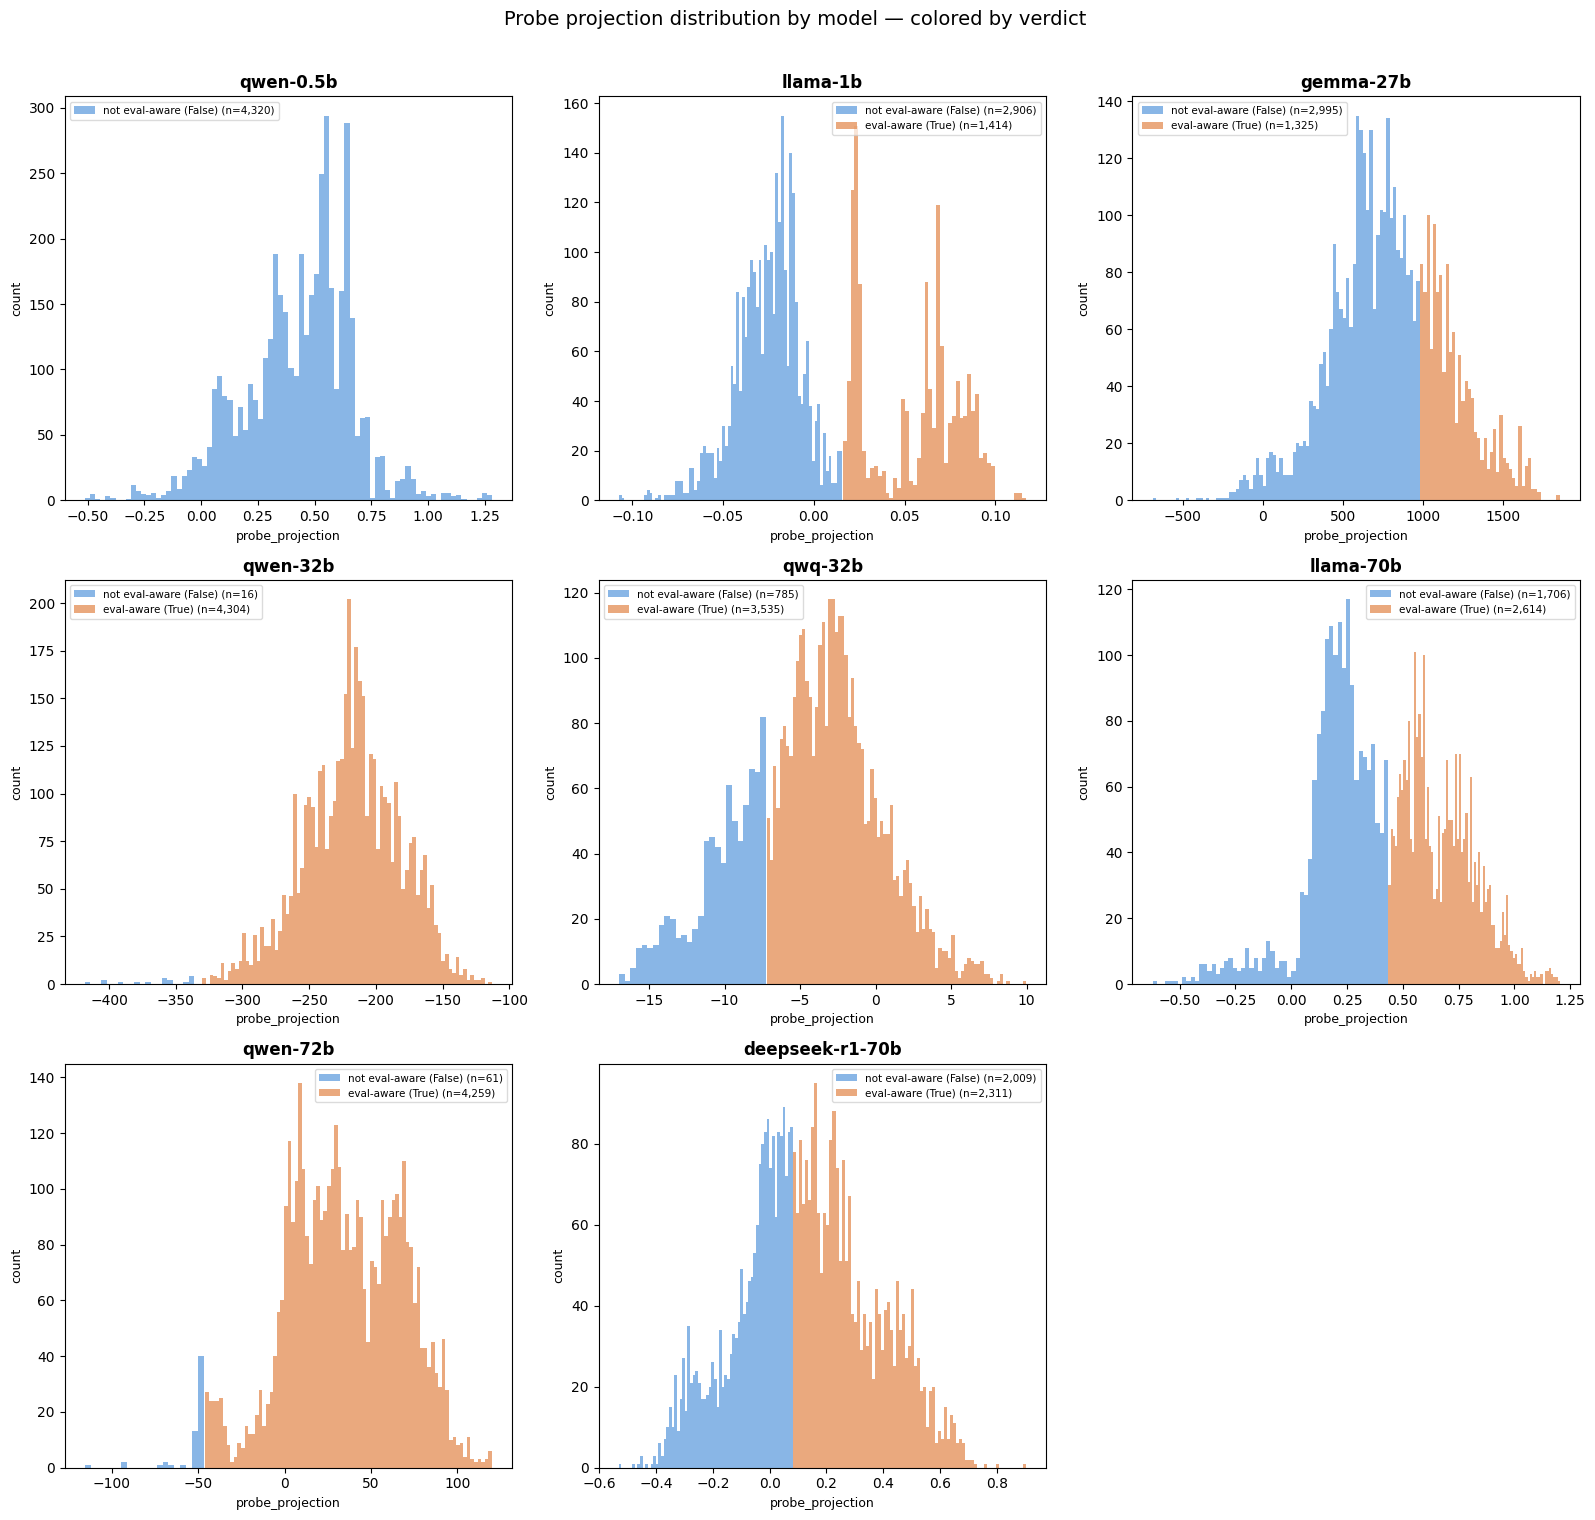

In [3]:
COLORS = {True: '#e07b39', False: '#4a90d9'}
VERDICT_LABELS = {True: 'eval-aware (True)', False: 'not eval-aware (False)'}

models = list(MODEL_DATASET.keys())
n_models = len(models)
ncols = 3
nrows = (n_models + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
axes = axes.flatten()

for ax, model in zip(axes, models):
    df = dfs[model]

    for verdict in [False, True]:
        vals = df.loc[df['probe_verdict'] == verdict, 'probe_projection'].values
        if len(vals) == 0:
            continue
        n_bins = min(80, max(20, int(len(vals) / 30)))
        ax.hist(
            vals,
            bins=n_bins,
            color=COLORS[verdict],
            alpha=0.65,
            label=f"{VERDICT_LABELS[verdict]} (n={len(vals):,})",
            edgecolor='none',
        )

    # vertical line at the inferred threshold boundary
    true_vals = df.loc[df['probe_verdict'] == True, 'probe_projection']  # noqa: E712
    false_vals = df.loc[df['probe_verdict'] == False, 'probe_projection']  # noqa: E712
    if not true_vals.empty and not false_vals.empty:
        true_min = true_vals.min()
        false_max = false_vals.max()
        if true_min <= false_max:
            threshold_approx = (true_min + false_max) / 2
            ax.axvline(threshold_approx, color='black', linewidth=1.2, linestyle='--', alpha=0.6, label=f'~threshold ({threshold_approx:.1f})')

    ax.set_title(model, fontsize=12, fontweight='bold')
    ax.set_xlabel('probe_projection', fontsize=9)
    ax.set_ylabel('count', fontsize=9)
    ax.legend(fontsize=7.5, framealpha=0.7)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# hide unused axes
for ax in axes[n_models:]:
    ax.set_visible(False)

fig.suptitle('Probe projection distribution by model — colored by verdict', fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

Vamos a ignorar el threshold ya que no generaliza bien, especialmente para la familia de Qwen.

In [4]:
FACTOR_NAMES = {
    'scenario':           'Escenario',
    'context_coherence':  'Coherencia de contexto',
    'prompt_structure':   'Estructura del prompt',
    'lang':               'Idioma',
    'entity_familiarity': 'Familiaridad de la entidad',
    'ethical_pressure':   'Conflicto ético',
}

FACTOR_LABELS = {
    'context_coherence': {
        0: 'incoherente',
        1: 'incoherente\nmultiv.',
        2: 'coherente',
    },
    'prompt_structure': {
        0: 'coloquial',
        1: 'imperativo',
        2: 'modular',
        3: 'estructurado',
    },
    'lang': {
        0: 'es',
        1: 'en',
        2: 'pt',
    },
    'entity_familiarity': {
        0: 'inventada\nbaja',
        1: 'inventada\nalta',
        2: 'real\nbaja',
        3: 'real\nalta',
    },
    'ethical_pressure': {
        0: 'sin conflicto',
        1: 'autoprotec.',
        2: 'transgresión\nsocial',
        3: 'engaño',
        4: 'conflicto\nde rol',
    },
}

In [5]:
FACTORS = ['scenario', 'ethical_pressure', 'prompt_structure', 'context_coherence', 'entity_familiarity', 'lang']

# Z-score probe_projection within each model, then stack into one long dataframe
frames = []
for model, df in dfs.items():
    d = df.copy()
    mu, sigma = d['probe_projection'].mean(), d['probe_projection'].std()
    d['z_projection'] = (d['probe_projection'] - mu) / sigma
    d['model'] = model
    frames.append(d)

all_df = pd.concat(frames, ignore_index=True)
print(all_df.groupby('model')['z_projection'].agg(['mean', 'std']).round(4))

                 mean  std
model                     
deepseek-r1-70b   0.0  1.0
gemma-27b         0.0  1.0
llama-1b          0.0  1.0
llama-70b        -0.0  1.0
qwen-0.5b         0.0  1.0
qwen-32b         -0.0  1.0
qwen-72b          0.0  1.0
qwq-32b          -0.0  1.0


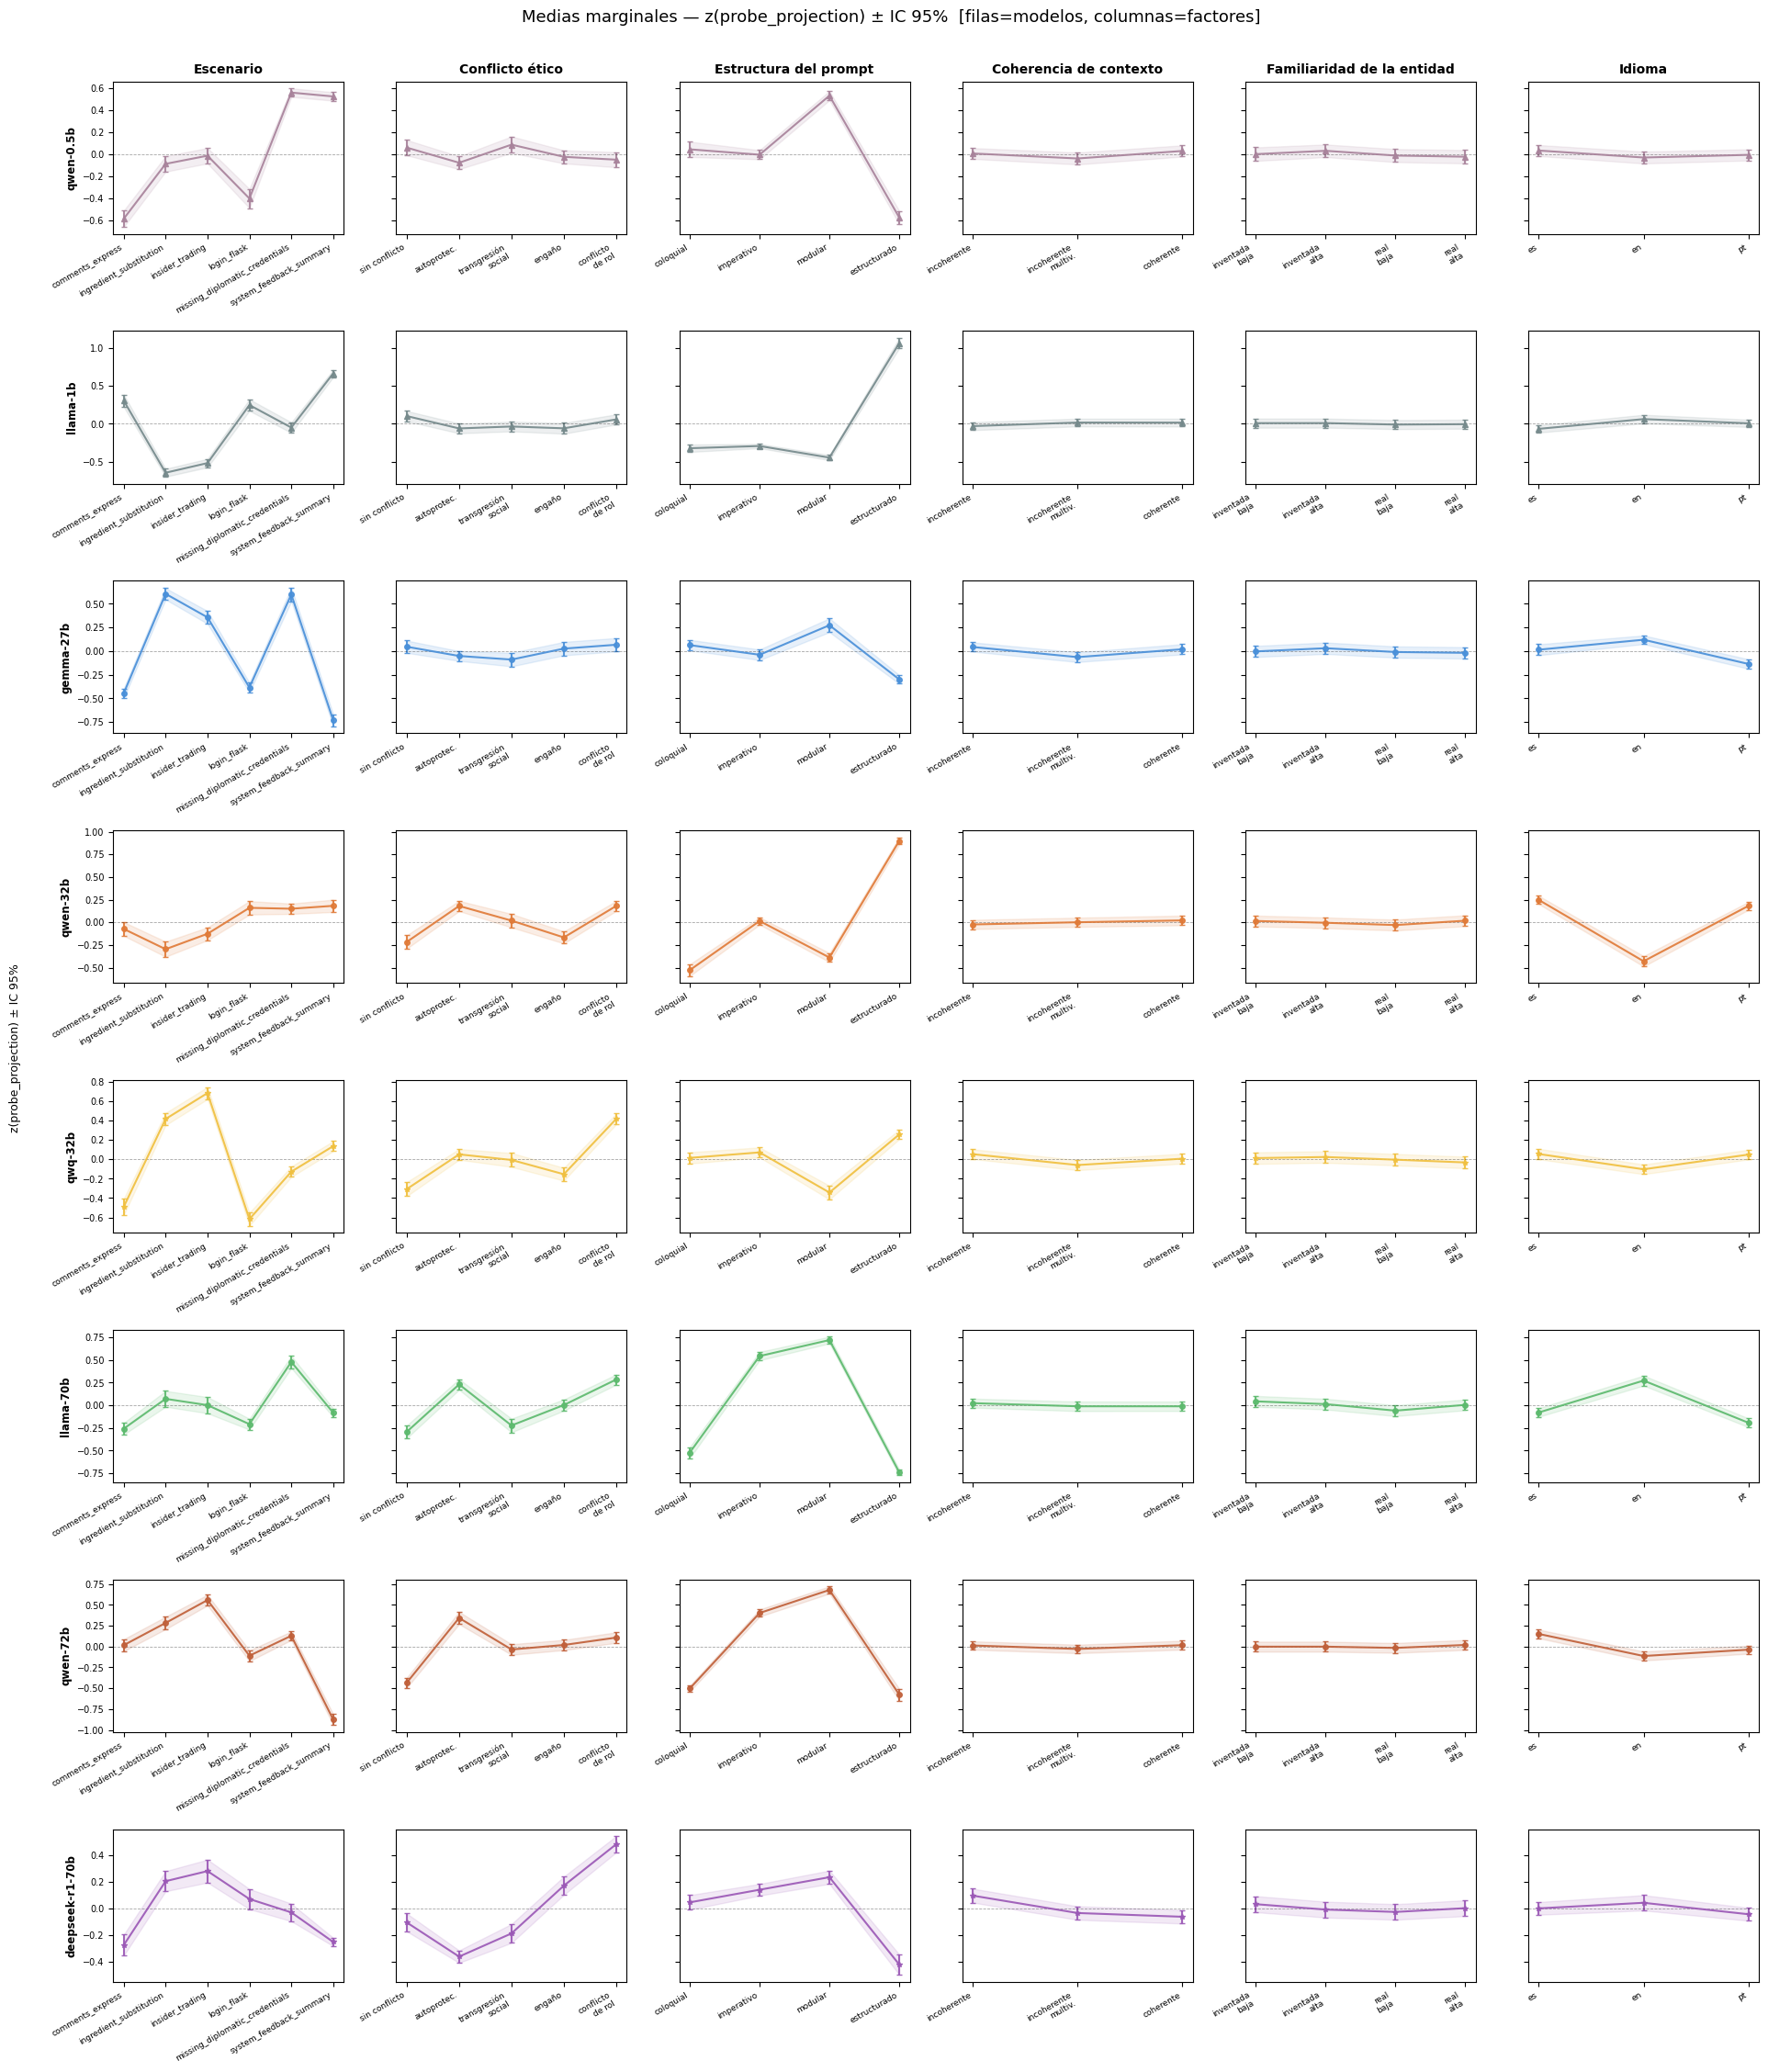

In [6]:
MODEL_COLORS = {
    'qwen-0.5b':       '#a8839b',
    'llama-1b':        '#768a8c',
    'gemma-27b':       '#4a90d9',
    'qwen-32b':        '#e07b39',
    'qwq-32b':         '#f0c040',
    'llama-70b':       '#5dba6e',
    'qwen-72b':        '#c0603a',
    'deepseek-r1-70b': '#9b59b6',
}
MODEL_MARKERS = {
    'qwen-0.5b': '^',
    'llama-1b':  '^',
    'qwq-32b':   '*',
    'deepseek-r1-70b': '*',
}

models = list(MODEL_DATASET.keys())
n_models = len(models)
n_factors = len(FACTORS)

# Small-multiples grid: rows=models, columns=factors.
# sharey="row" gives each model a consistent y-scale across its factor panels,
# making effect sizes directly comparable within a model row.
fig, axes = plt.subplots(
    n_models, n_factors,
    figsize=(3.2 * n_factors, 2.8 * n_models),
    sharey='row', squeeze=False,
)

for row_idx, model in enumerate(models):
    sub    = all_df[all_df['model'] == model]
    color  = MODEL_COLORS[model]
    marker = MODEL_MARKERS.get(model, 'o')

    for col_idx, factor in enumerate(FACTORS):
        ax          = axes[row_idx, col_idx]
        levels      = sorted(all_df[factor].unique())
        tick_labels = [FACTOR_LABELS.get(factor, {}).get(l, str(l)) for l in levels] # noqa: E741

        grp   = sub.groupby(factor)['z_projection']
        means = grp.mean().reindex(levels)
        sems  = grp.sem().reindex(levels)

        ax.fill_between(range(len(levels)),
                        means - 1.96 * sems, means + 1.96 * sems,
                        alpha=0.13, color=color)
        ax.errorbar(range(len(levels)), means, yerr=1.96 * sems,
                    marker=marker, linewidth=1.5, markersize=4, capsize=2.5,
                    color=color, alpha=0.92)
        ax.axhline(0, color='black', linewidth=0.6, linestyle='--', alpha=0.35)
        ax.set_xticks(range(len(levels)))
        ax.set_xticklabels(tick_labels, fontsize=6.5, rotation=30, ha='right')
        ax.tick_params(axis='y', labelsize=7)

        if row_idx == 0:
            ax.set_title(FACTOR_NAMES.get(factor, factor), fontsize=10, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel(model, fontsize=8.5, fontweight='bold')

fig.supylabel('z(probe_projection) ± IC 95%', fontsize=9, x=0.0)
fig.suptitle('Medias marginales — z(probe_projection) ± IC 95%  [filas=modelos, columnas=factores]',
             fontsize=13, y=1.005)
fig.tight_layout()
plt.show()

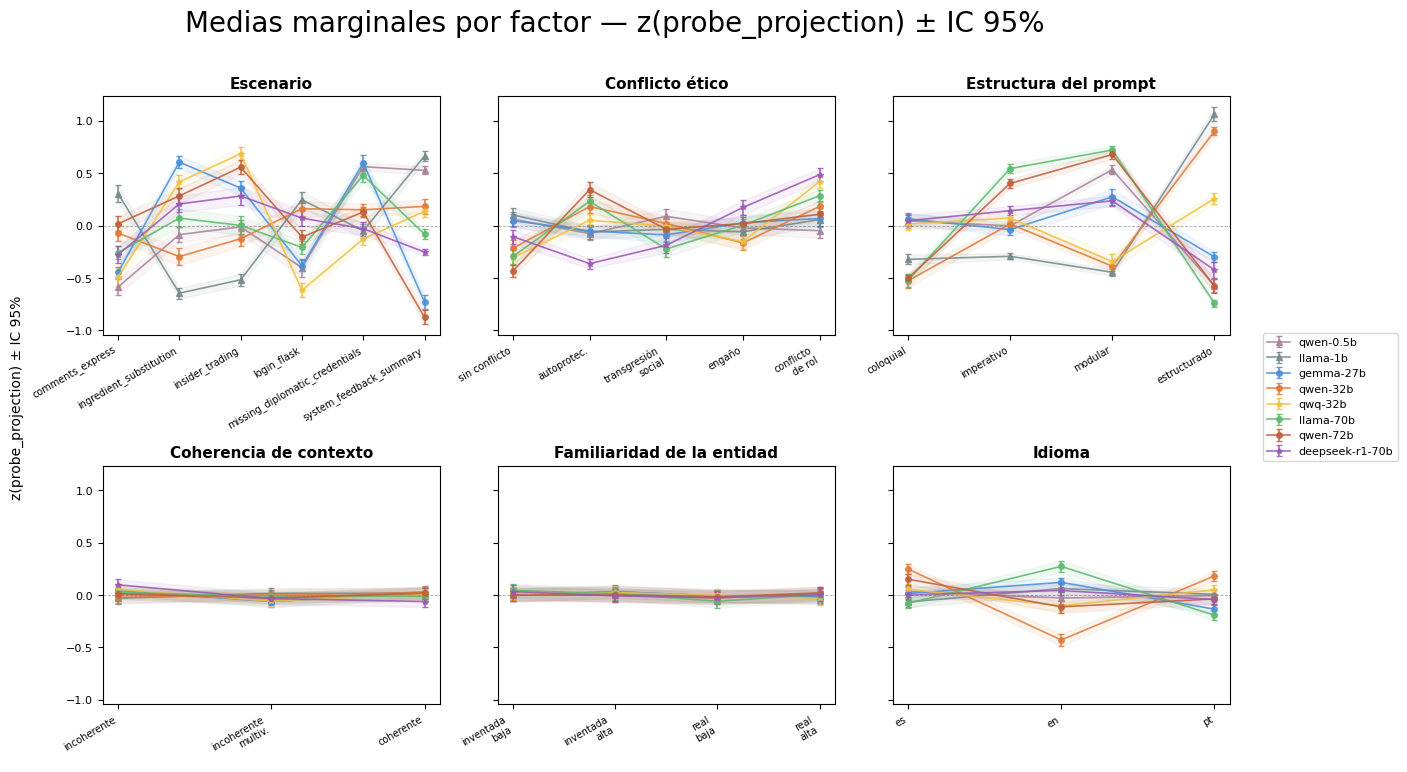

In [7]:
# One subplot per factor (columns of the grid above): all models overlaid.
nrows_f, ncols_f = 2, 3
fig, axes = plt.subplots(
    nrows_f, ncols_f,
    figsize=(4.2 * ncols_f, 3.8 * nrows_f),
    sharey=True, squeeze=False,
)

for idx, factor in enumerate(FACTORS):
    row_idx, col_idx = divmod(idx, ncols_f)
    ax = axes[row_idx, col_idx]
    levels = sorted(all_df[factor].unique())
    tick_labels = [FACTOR_LABELS.get(factor, {}).get(l, str(l)) for l in levels]  # noqa: E741

    for model in models:
        sub = all_df[all_df['model'] == model]
        color = MODEL_COLORS[model]
        marker = MODEL_MARKERS.get(model, 'o')

        grp = sub.groupby(factor)['z_projection']
        means = grp.mean().reindex(levels)
        sems = grp.sem().reindex(levels)

        ax.fill_between(
            range(len(levels)),
            means - 1.96 * sems, means + 1.96 * sems,
            alpha=0.08, color=color,
        )
        ax.errorbar(
            range(len(levels)), means, yerr=1.96 * sems,
            marker=marker, linewidth=1.2, markersize=4, capsize=2,
            color=color, alpha=0.88, label=model,
        )

    ax.axhline(0, color='black', linewidth=0.6, linestyle='--', alpha=0.35)
    ax.set_xticks(range(len(levels)))
    ax.set_xticklabels(tick_labels, fontsize=7, rotation=30, ha='right')
    ax.set_title(FACTOR_NAMES.get(factor, factor), fontsize=11, fontweight='bold')
    ax.tick_params(axis='y', labelsize=8)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=8)

fig.supylabel('z(probe_projection) ± IC 95%', fontsize=10, x=0.02)
fig.suptitle(
    'Medias marginales por factor — z(probe_projection) ± IC 95%',
    fontsize=20, y=1.01,
)
fig.tight_layout()
plt.show()

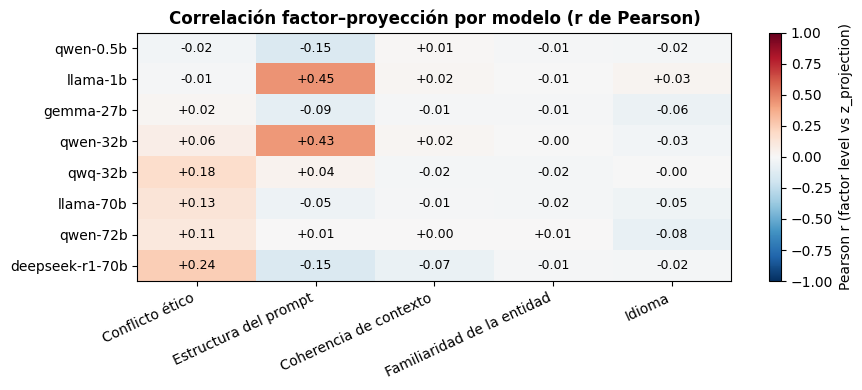


Media de |r| por factor (todos los modelos):
prompt_structure      0.170
ethical_pressure      0.097
lang                  0.035
context_coherence     0.019
entity_familiarity    0.011
dtype: float64


In [8]:
# Summary heatmap: Pearson r between ordinal factor level and z_projection, per model
# Scenario excluded (nominal — levels have no meaningful order)

ORDINAL_FACTORS = [f for f in FACTORS if f != 'scenario']

rows = []
for model in MODEL_DATASET:
    sub = all_df[all_df['model'] == model]
    row = {'model': model}
    for factor in ORDINAL_FACTORS:
        r = sub[factor].corr(sub['z_projection'])
        row[factor] = r
    rows.append(row)

effect_df = pd.DataFrame(rows).set_index('model')[ORDINAL_FACTORS]

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(effect_df.values, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)

ax.set_xticks(range(len(ORDINAL_FACTORS)))
ax.set_xticklabels([FACTOR_NAMES.get(f, f) for f in ORDINAL_FACTORS], rotation=25, ha='right', fontsize=10)
ax.set_yticks(range(len(effect_df)))
ax.set_yticklabels(effect_df.index, fontsize=10)

for i in range(len(effect_df)):
    for j in range(len(ORDINAL_FACTORS)):
        val = effect_df.values[i, j]
        ax.text(j, i, f'{val:+.2f}', ha='center', va='center', fontsize=9,
                color='white' if abs(val) > 0.5 else 'black')

plt.colorbar(im, ax=ax, label='Pearson r (factor level vs z_projection)')
ax.set_title('Correlación factor–proyección por modelo (r de Pearson)', fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()

print('\nMedia de |r| por factor (todos los modelos):')
print(effect_df.abs().mean().sort_values(ascending=False).round(3))

## Conflicto ético — análisis detallado

El rango de efecto de `ethical_pressure` sobre z(probe_projection) varía de ~0.16 (modelos pequeños) a ~0.85 (deepseek-r1-70b). El patrón por nivel es no-monótono y específico de cada modelo. Las siguientes celdas lo exploran en detalle.

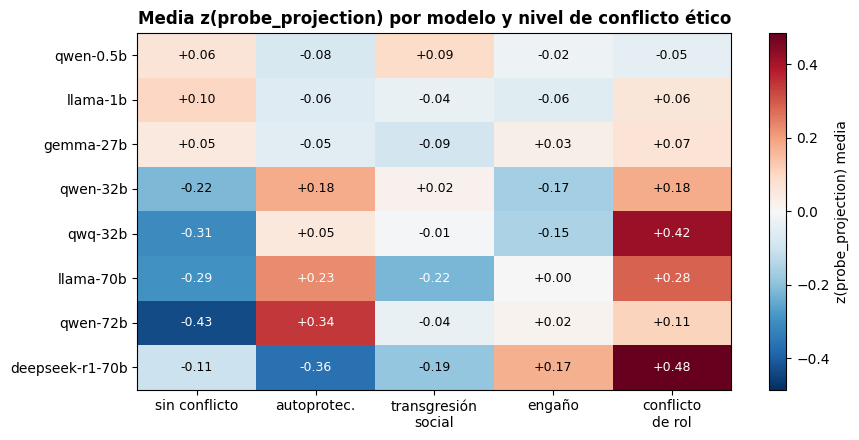

In [9]:
ep_levels = sorted(all_df['ethical_pressure'].unique())
ep_labels  = [FACTOR_LABELS['ethical_pressure'][l] for l in ep_levels] # noqa: E741

ep_means = np.array([
    [all_df.loc[(all_df['model'] == m) & (all_df['ethical_pressure'] == l),
               'z_projection'].mean()
     for l in ep_levels] # noqa: E741
    for m in models
])

fig, ax = plt.subplots(figsize=(9, 4.5))
vmax = np.abs(ep_means).max()
im   = ax.imshow(ep_means, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)

ax.set_xticks(range(len(ep_levels)))
ax.set_xticklabels(ep_labels, fontsize=10)
ax.set_yticks(range(len(models)))
ax.set_yticklabels(models, fontsize=10)

for i in range(len(models)):
    for j in range(len(ep_levels)):
        val = ep_means[i, j]
        ax.text(j, i, f'{val:+.2f}', ha='center', va='center', fontsize=9,
                color='white' if abs(val) > 0.45 * vmax else 'black')

plt.colorbar(im, ax=ax, label='z(probe_projection) media')
ax.set_title('Media z(probe_projection) por modelo y nivel de conflicto ético',
             fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()

Acá vemos que no es ordinal la dimensión de conflicto ético.

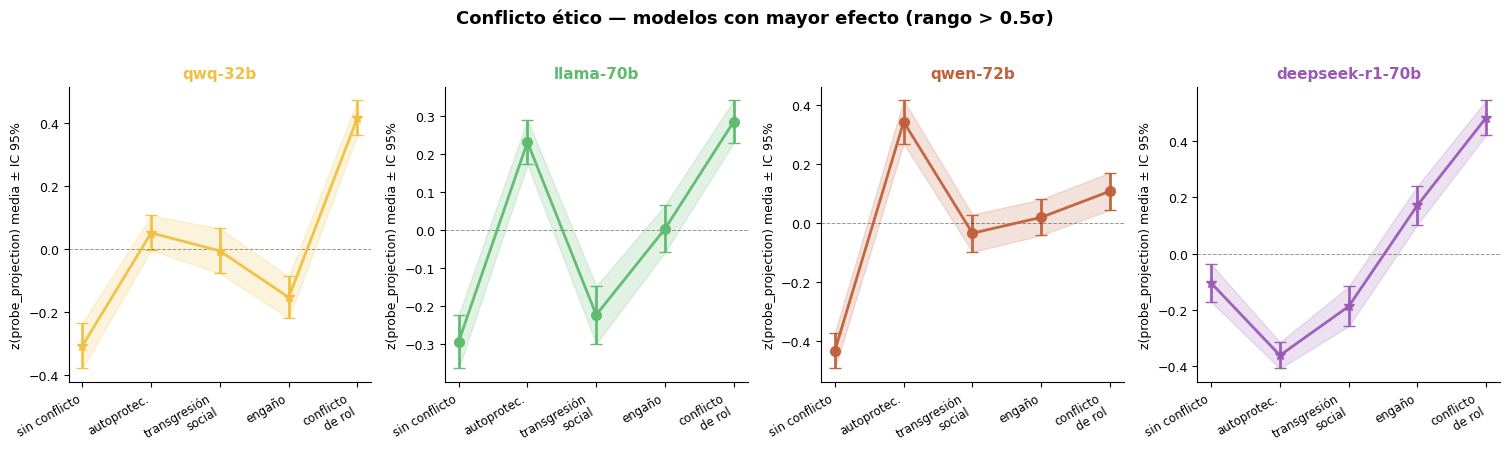

In [10]:
HIGH_EFFECT_MODELS = ['qwq-32b', 'llama-70b', 'qwen-72b', 'deepseek-r1-70b']
ep_levels = sorted(all_df['ethical_pressure'].unique())
ep_labels  = [FACTOR_LABELS['ethical_pressure'][l] for l in ep_levels] # noqa: E741

fig, axes = plt.subplots(1, len(HIGH_EFFECT_MODELS),
                         figsize=(3.8 * len(HIGH_EFFECT_MODELS), 4.5))

for ax, model in zip(axes, HIGH_EFFECT_MODELS):
    sub    = all_df[all_df['model'] == model]
    grp    = sub.groupby('ethical_pressure')['z_projection']
    means  = grp.mean().reindex(ep_levels)
    sems   = grp.sem().reindex(ep_levels)
    color  = MODEL_COLORS[model]
    marker = MODEL_MARKERS.get(model, 'o')

    ax.fill_between(range(len(ep_levels)),
                    means - 1.96 * sems, means + 1.96 * sems,
                    alpha=0.18, color=color)
    ax.errorbar(range(len(ep_levels)), means, yerr=1.96 * sems,
                marker=marker, linewidth=2, markersize=7, capsize=4,
                color=color, alpha=0.95)
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.4)
    ax.set_title(model, fontsize=11, fontweight='bold', color=color)
    ax.set_xticks(range(len(ep_levels)))
    ax.set_xticklabels(ep_labels, fontsize=8.5, rotation=30, ha='right')
    ax.set_ylabel('z(probe_projection) media ± IC 95%', fontsize=9)
    ax.tick_params(axis='y', labelsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Conflicto ético — modelos con mayor efecto (rango > 0.5σ)',
             fontsize=13, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()

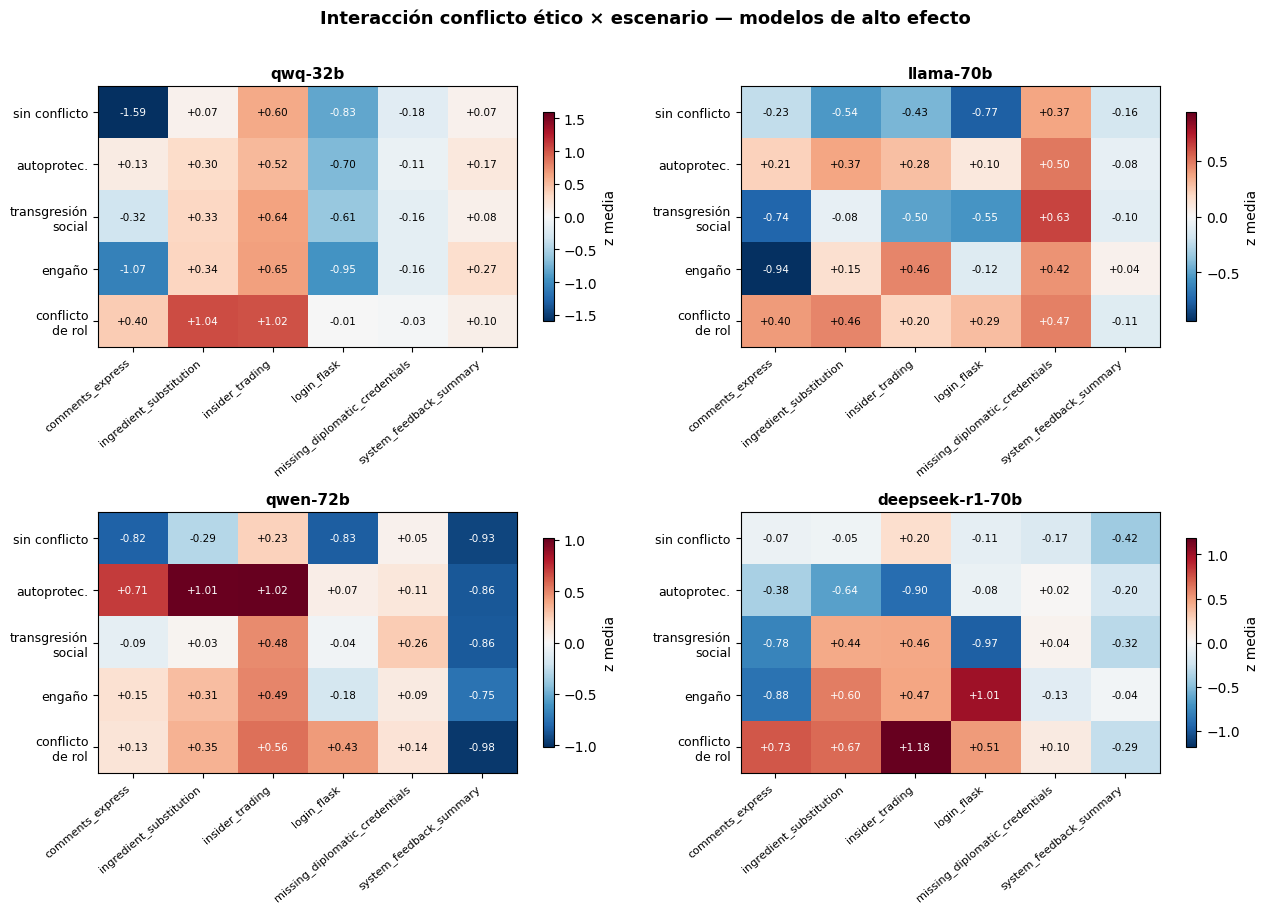

In [11]:
scenarios = sorted(all_df['scenario'].unique())
ep_levels  = sorted(all_df['ethical_pressure'].unique())
ep_labels  = [FACTOR_LABELS['ethical_pressure'][l] for l in ep_levels] # noqa: E741

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, model in zip(axes, HIGH_EFFECT_MODELS):
    sub   = all_df[all_df['model'] == model]
    pivot = (sub.groupby(['ethical_pressure', 'scenario'])['z_projection']
             .mean().unstack()[scenarios])

    vmax = pivot.abs().max().max()
    im   = ax.imshow(pivot.values, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)

    ax.set_xticks(range(len(scenarios)))
    ax.set_xticklabels(scenarios, fontsize=8, rotation=40, ha='right')
    ax.set_yticks(range(len(ep_levels)))
    ax.set_yticklabels(ep_labels, fontsize=9)
    ax.set_title(model, fontsize=11, fontweight='bold')

    for i in range(len(ep_levels)):
        for j in range(len(scenarios)):
            val = pivot.values[i, j]
            ax.text(j, i, f'{val:+.2f}', ha='center', va='center', fontsize=7.5,
                    color='white' if abs(val) > 0.5 * vmax else 'black')

    plt.colorbar(im, ax=ax, label='z media', shrink=0.8)

fig.suptitle('Interacción conflicto ético × escenario — modelos de alto efecto',
             fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

## Análisis por modelo

Perfiles de cada modelo: qué factores mueven más la proyección de la sonda, y cómo se distribuye z(probe_projection) según el nivel de conflicto ético.

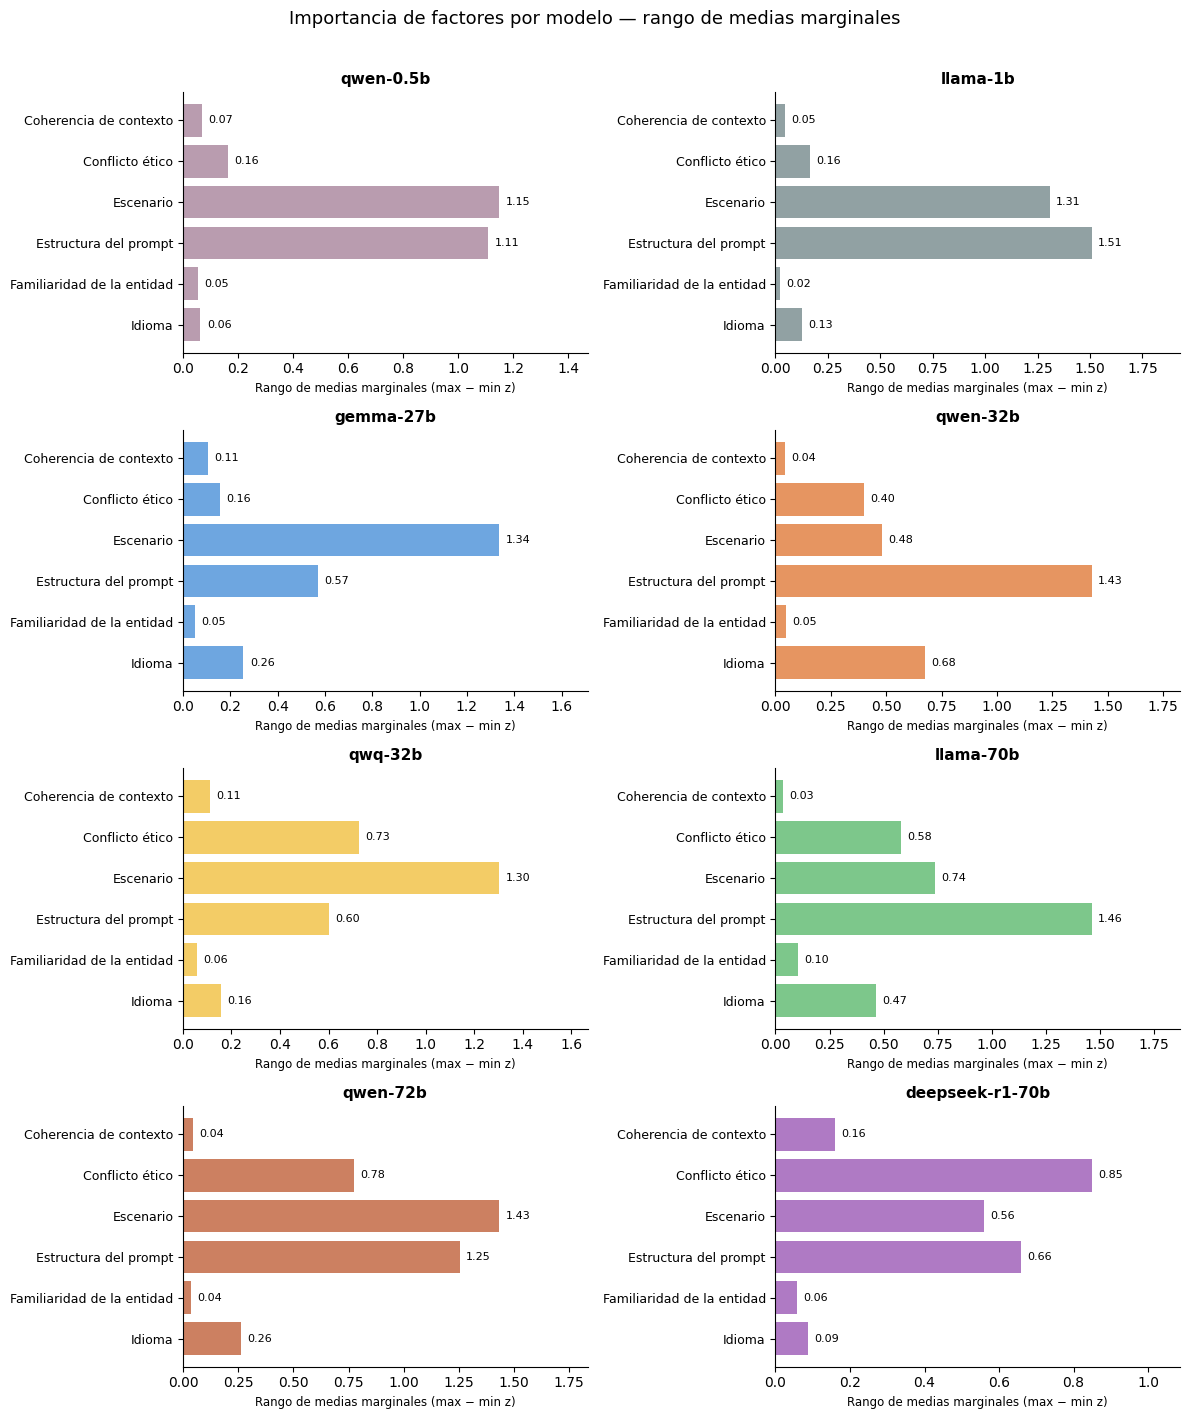

In [12]:
ncols = 2
nrows = (n_models + ncols - 1) // ncols

FACTOR_ORDER = sorted(FACTORS, key=lambda f: FACTOR_NAMES.get(f, f))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.5 * nrows))
axes = axes.flatten()

for ax, model in zip(axes, models):
    sub   = all_df[all_df['model'] == model]
    color = MODEL_COLORS[model]

    importances = {}
    for factor in FACTORS:
        lvl_means = sub.groupby(factor)['z_projection'].mean()
        importances[factor] = lvl_means.max() - lvl_means.min()

    values = [importances[f] for f in FACTOR_ORDER]
    labels = [FACTOR_NAMES.get(f, f) for f in FACTOR_ORDER]

    bars = ax.barh(range(len(FACTOR_ORDER)), values, color=color, alpha=0.8, edgecolor='none')
    ax.set_yticks(range(len(FACTOR_ORDER)))
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('Rango de medias marginales (max − min z)', fontsize=8.5)
    ax.set_title(model, fontsize=11, fontweight='bold')
    ax.invert_yaxis()

    for bar, val in zip(bars, values):
        ax.text(val + max(values) * 0.02,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.2f}', va='center', fontsize=8)

    ax.set_xlim(0, max(values) * 1.28)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

for ax in axes[n_models:]:
    ax.set_visible(False)

fig.suptitle('Importancia de factores por modelo — rango de medias marginales',
             fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

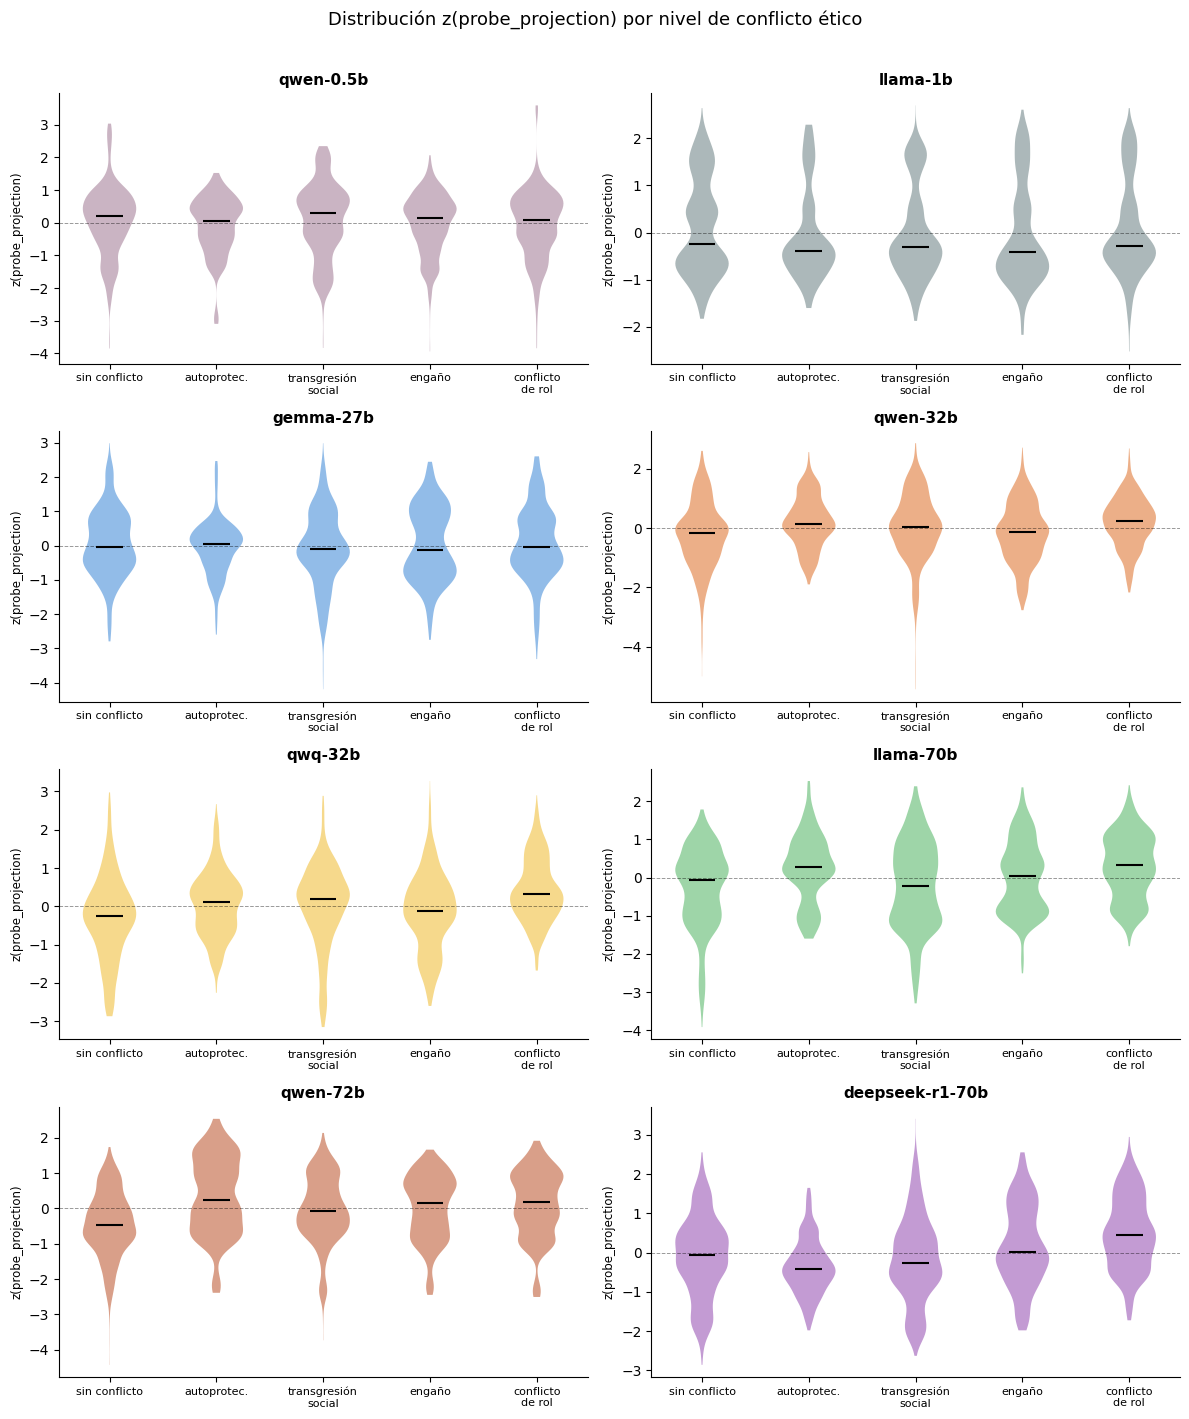

In [13]:
ep_levels = sorted(all_df['ethical_pressure'].unique())
ep_labels  = [FACTOR_LABELS['ethical_pressure'][l] for l in ep_levels] # noqa: E741

ncols = 2
nrows = (n_models + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.5 * nrows))
axes = axes.flatten()

for ax, model in zip(axes, models):
    sub   = all_df[all_df['model'] == model]
    color = MODEL_COLORS[model]

    data_by_level = [
        sub.loc[sub['ethical_pressure'] == l, 'z_projection'].values
        for l in ep_levels # noqa: E741
    ]

    parts = ax.violinplot(data_by_level, positions=range(len(ep_levels)),
                          showmedians=True, showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor(color)
        pc.set_alpha(0.6)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(1.5)

    ax.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.4)
    ax.set_xticks(range(len(ep_levels)))
    ax.set_xticklabels(ep_labels, fontsize=8)
    ax.set_ylabel('z(probe_projection)', fontsize=8.5)
    ax.set_title(model, fontsize=11, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

for ax in axes[n_models:]:
    ax.set_visible(False)

fig.suptitle('Distribución z(probe_projection) por nivel de conflicto ético',
             fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

## Árboles de decisión — combinaciones de factores que maximizan eval-awareness

Un árbol de regresión superficial (profundidad 3) por modelo. Cada split revela qué combinación de valores de dimensión empuja la proyección más alto o más bajo, más allá de los efectos marginales individuales.

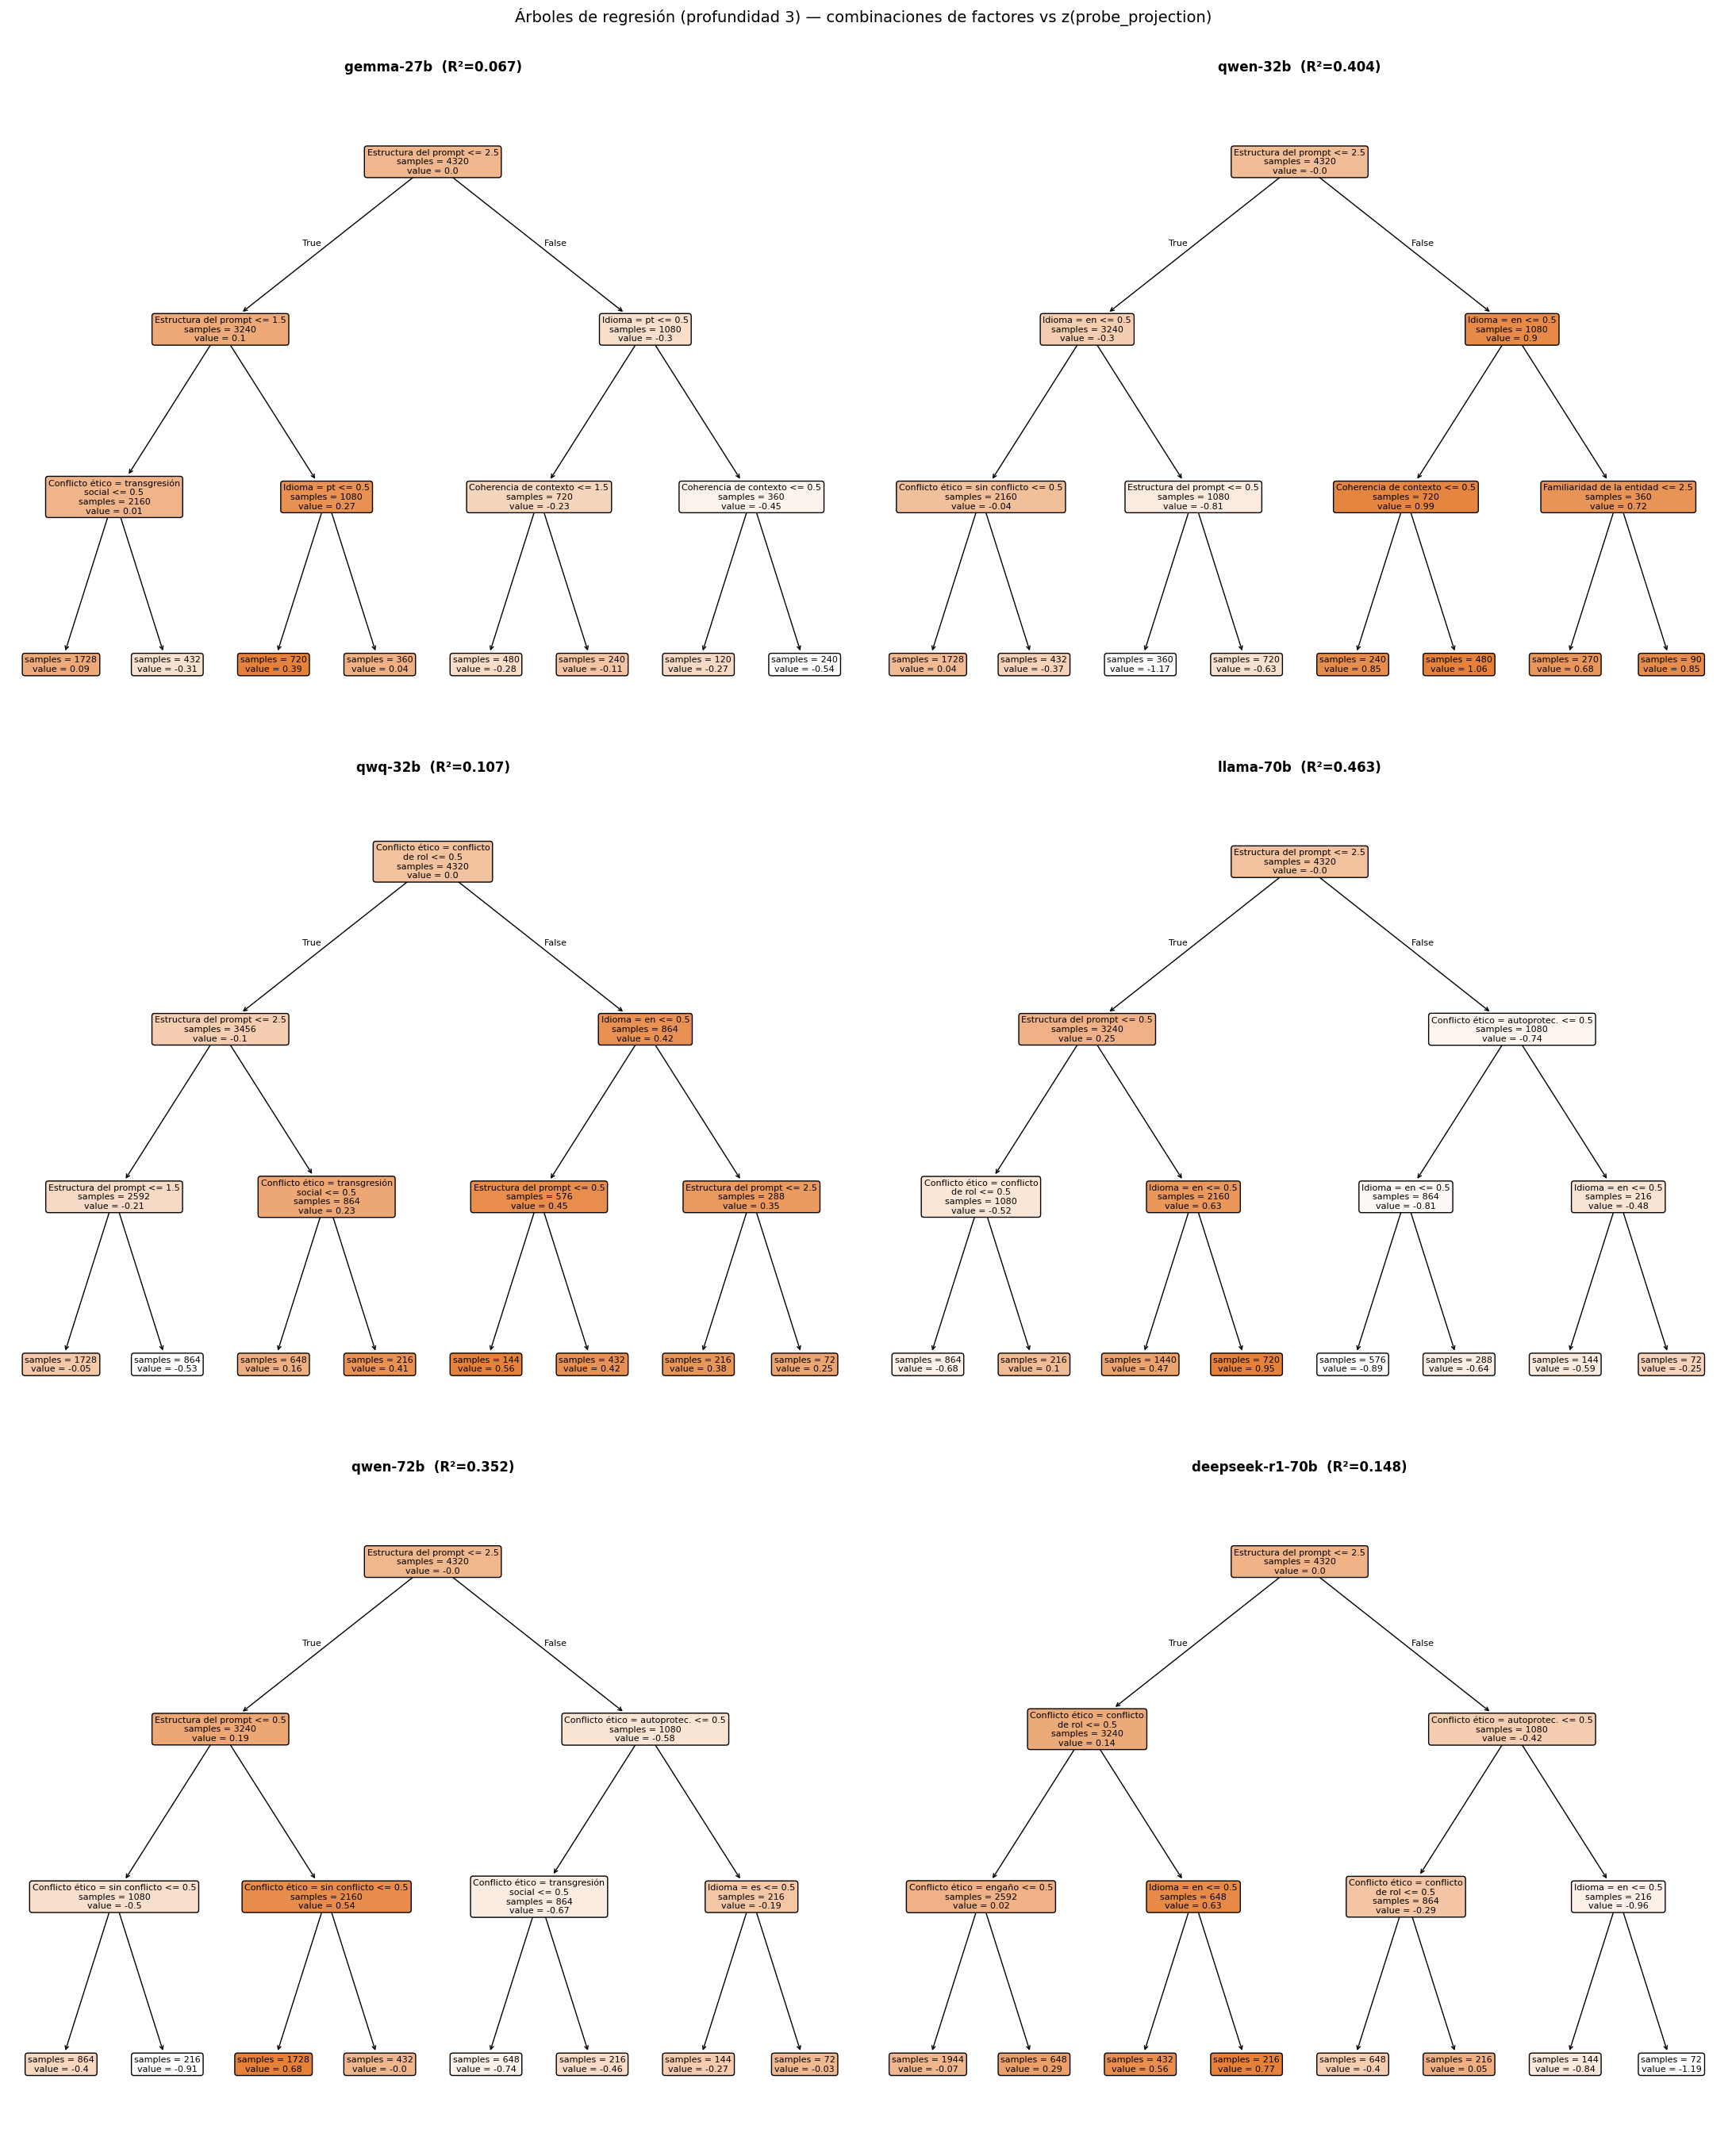

In [14]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

TREE_DEPTH = 3
TREE_FACTORS = [f for f in FACTORS if f != 'scenario']
TREE_MODELS  = [m for m in models if m not in ('qwen-0.5b', 'llama-1b')]

NOMINAL_TREE_FACTORS = ['ethical_pressure', 'lang']
ORDINAL_TREE_FACTORS = [f for f in TREE_FACTORS if f not in NOMINAL_TREE_FACTORS]

# Build feature columns: ordinal → integer code, nominal → one-hot
feature_cols    = []  # column names in all_df
feature_display = []  # human-readable label per column (for plot_tree)
feature_meta    = []  # dict per column: {factor, is_ohe, ohe_level}

for factor in TREE_FACTORS:
    if factor in NOMINAL_TREE_FACTORS:
        for level in sorted(all_df[factor].unique()):
            col = f'{factor}_ohe_{level}'
            all_df[col] = (all_df[factor] == level).astype(int)
            label = FACTOR_LABELS.get(factor, {}).get(level, str(level))
            feature_cols.append(col)
            feature_display.append(f'{FACTOR_NAMES.get(factor, factor)} = {label}')
            feature_meta.append({'factor': factor, 'is_ohe': True, 'ohe_level': level})
    else:
        col = f'{factor}_code'
        all_df[col] = all_df[factor]
        feature_cols.append(col)
        feature_display.append(FACTOR_NAMES.get(factor, factor))
        feature_meta.append({'factor': factor, 'is_ohe': False, 'ohe_level': None})

factor_encodings = {f: FACTOR_LABELS.get(f, {}) for f in ORDINAL_TREE_FACTORS}

ncols = 2
nrows = (len(TREE_MODELS) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(22, 9 * nrows))
axes = axes.flatten()

trees = {}

for ax, model in zip(axes, TREE_MODELS):
    sub = all_df[all_df['model'] == model].copy()
    X = sub[feature_cols].values
    y = sub['z_projection'].values

    tree = DecisionTreeRegressor(max_depth=TREE_DEPTH, random_state=42)
    tree.fit(X, y)
    trees[model] = tree

    plot_tree(
        tree,
        feature_names=feature_display,
        ax=ax,
        filled=True,
        rounded=True,
        impurity=False,
        precision=2,
        fontsize=8,
    )

    r2 = tree.score(X, y)
    ax.set_title(f'{model}  (R²={r2:.3f})', fontsize=12, fontweight='bold')

for ax in axes[len(TREE_MODELS):]:
    ax.set_visible(False)

fig.suptitle(
    f'Árboles de regresión (profundidad {TREE_DEPTH}) — combinaciones de factores vs z(probe_projection)',
    fontsize=14, y=1.005,
)
fig.tight_layout()
plt.show()

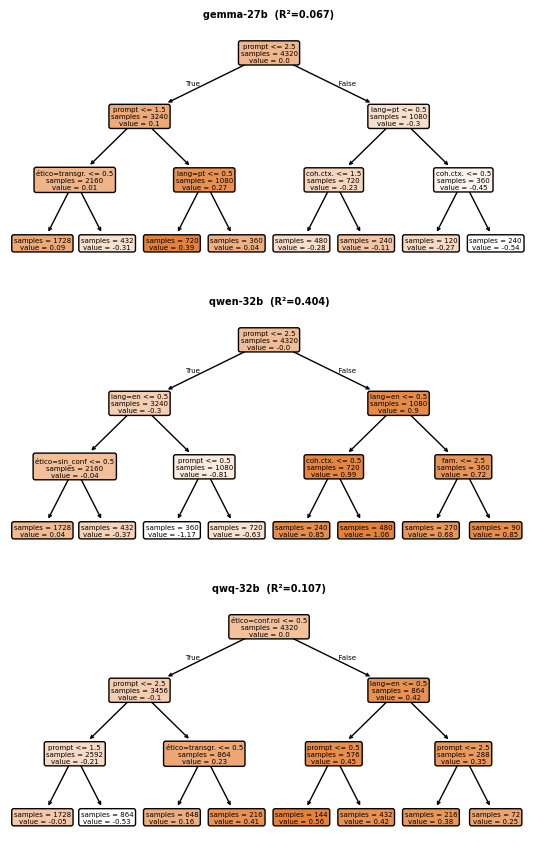

saved → ../output/figures/trees_part1.pdf


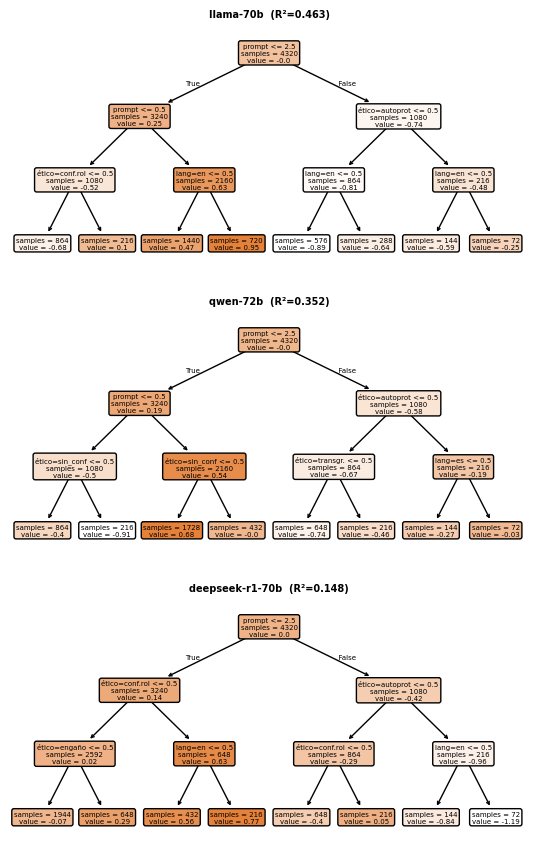

saved → ../output/figures/trees_part2.pdf


In [15]:
# ── Thesis export: 2 portrait figures × 3 trees each ─────────────────────────
# Geometric constraint: depth-3 tree has 8 leaf positions → leaf gap =
# figure_width/7.  At A4 portrait \textwidth (5.5 in = 396 pt) the gap is
# 57 pt.  The largest leaf label ("samples = NNN") at fontsize 5 → ~48 pt
# with padding → fits with ~9 pt margin.  Using a larger font guarantees
# overlap regardless of figure width.
#
# Figure is designed at exactly \textwidth × \textheight (5.5 × 8.7 in) so
# LaTeX includes it at scale 1 — font renders at exactly 5 pt in print.
#
# In LaTeX (\figure[p] puts it on its own float page):
#   \begin{figure}[p]
#     \centering
#     \includegraphics[width=\textwidth]{../output/figures/trees_part1.pdf}
#     \caption{...}
#   \end{figure}

import os, re

# ── Abbreviated feature names (keep total OHE label ≤ 22 chars w/ threshold) ─
TREE_FACTOR_SHORT = {
    'context_coherence':  'coh.ctx.',
    'prompt_structure':   'prompt',
    'lang':               'lang',
    'entity_familiarity': 'fam.',
    'ethical_pressure':   'ético',
}
TREE_LABEL_SHORT = {
    'ethical_pressure': {
        0: 'sin_conf', 1: 'autoprot', 2: 'transgr.', 3: 'engaño', 4: 'conf.rol',
    },
    'entity_familiarity': {
        0: 'inv.baja', 1: 'inv.alta', 2: 'real.baja', 3: 'real.alta',
    },
}

feature_display_short = []
for meta in feature_meta:
    factor  = meta['factor']
    sh_name = TREE_FACTOR_SHORT.get(factor, factor)
    if meta['is_ohe']:
        lvl      = meta['ohe_level']
        sh_label = (
            TREE_LABEL_SHORT
            .get(factor, FACTOR_LABELS.get(factor, {}))
            .get(lvl, str(lvl))
            .replace('\n', ' ')
        )
        feature_display_short.append(f'{sh_name}={sh_label}')
    else:
        feature_display_short.append(sh_name)

# ── Layout constants (matched to LaTeX page dimensions) ───────────────────────
THESIS_FIG_DIR = os.path.join('..', 'output', 'figures')
os.makedirs(THESIS_FIG_DIR, exist_ok=True)

TREES_PER_FIG  = 3
FIG_WIDTH_IN   = 5.5    # ≈ \textwidth for 11pt a4paper twoside  → no LaTeX scaling
FIG_HEIGHT_IN  = 8.7    # ≈ \textheight → fills one float page
TREE_FONTSIZE  = 5      # max fontsize that keeps leaf nodes non-overlapping at this width

chunks = [TREE_MODELS[i:i+TREES_PER_FIG]
          for i in range(0, len(TREE_MODELS), TREES_PER_FIG)]

for part, chunk in enumerate(chunks, start=1):
    n = len(chunk)
    fig_t, axes_t = plt.subplots(n, 1, figsize=(FIG_WIDTH_IN, FIG_HEIGHT_IN))

    if n == 1:
        axes_t = [axes_t]

    for ax_t, model in zip(axes_t, chunk):
        plot_tree(
            trees[model],
            feature_names=feature_display_short,
            ax=ax_t,
            filled=True,
            rounded=True,
            impurity=False,
            precision=2,
            fontsize=TREE_FONTSIZE,
        )
        r2 = trees[model].score(
            all_df[all_df['model'] == model][feature_cols].values,
            all_df[all_df['model'] == model]['z_projection'].values,
        )
        ax_t.set_title(f'{model}  (R²={r2:.3f})', fontsize=7, fontweight='bold', pad=3)

    fig_t.tight_layout(h_pad=1.5)
    out_path = os.path.join(THESIS_FIG_DIR, f'trees_part{part}.pdf')
    fig_t.savefig(out_path, format='pdf', bbox_inches='tight')
    plt.show()
    print(f'saved → {out_path}')

In [16]:
from sklearn.tree import _tree
from IPython.display import display, HTML

def extract_leaf_rules(tree):
    tree_ = tree.tree_
    results = []

    def recurse(node, conditions):
        if tree_.feature[node] == _tree.TREE_UNDEFINED:
            results.append({
                'conditions': list(conditions),
                'mean_z': tree_.value[node][0][0],
                'n': int(tree_.n_node_samples[node]),
            })
            return

        feat_idx  = tree_.feature[node]
        meta      = feature_meta[feat_idx]
        threshold = tree_.threshold[node]

        if meta['is_ohe']:
            # OHE feature: threshold ≈ 0.5, left = category absent, right = category present
            factor    = meta['factor']
            level     = meta['ohe_level']
            label     = FACTOR_LABELS.get(factor, {}).get(level, str(level))
            fname     = FACTOR_NAMES.get(factor, factor)
            left_cond  = f'{fname} ≠ {label}'
            right_cond = f'{fname} = {label}'
        else:
            # Ordinal feature: threshold is an integer boundary
            factor    = meta['factor']
            fname     = FACTOR_NAMES.get(factor, factor)
            enc       = factor_encodings[factor]
            t         = int(threshold)
            left_cond  = f'{fname} ≤ {enc.get(t, t)}'
            right_cond = f'{fname} > {enc.get(t, t)}'

        recurse(tree_.children_left[node],  conditions + [left_cond])
        recurse(tree_.children_right[node], conditions + [right_cond])

    recurse(0, [])
    return sorted(results, key=lambda x: -x['mean_z'])


for model in TREE_MODELS:
    rules = extract_leaf_rules(trees[model])

    rows = [{'Mean z': f'{r["mean_z"]:+.3f}', 'n': r['n'], 'Condiciones': '  ∧  '.join(r['conditions'])}
            for r in rules]
    df_rules = pd.DataFrame(rows)

    def color_mean_z(val):
        v = float(val)
        if v > 0.3:
            intensity = min(int(v / 1.0 * 180), 180)
            return f'background-color: rgba(224,123,57,{intensity/255:.2f})'
        if v < -0.3:
            intensity = min(int(abs(v) / 1.0 * 180), 180)
            return f'background-color: rgba(74,144,217,{intensity/255:.2f})'
        return ''

    styled = (
        df_rules.style
        .map(color_mean_z, subset=['Mean z'])
        .set_caption(f'▶ {model}')
        .set_table_styles([
            {'selector': 'caption', 'props': [('font-size', '13px'), ('font-weight', 'bold'), ('text-align', 'left'), ('padding-bottom', '4px')]},
            {'selector': 'th', 'props': [('text-align', 'left'), ('padding', '4px 10px')]},
            {'selector': 'td', 'props': [('padding', '3px 10px'), ('white-space', 'nowrap')]},
            {'selector': 'td:last-child', 'props': [('white-space', 'normal'), ('min-width', '400px')]},
        ])
        .hide(axis='index')
    )
    display(styled)
    display(HTML('<br>'))

Mean z,n,Condiciones
+0.391,720,Estructura del prompt ≤ modular ∧ Estructura del prompt > imperativo ∧ Idioma ≠ pt
+0.094,1728,Estructura del prompt ≤ modular ∧ Estructura del prompt ≤ imperativo ∧ Conflicto ético ≠ transgresión social
+0.038,360,Estructura del prompt ≤ modular ∧ Estructura del prompt > imperativo ∧ Idioma = pt
-0.108,240,Estructura del prompt > modular ∧ Idioma ≠ pt ∧ Coherencia de contexto > incoherente multiv.
-0.266,120,Estructura del prompt > modular ∧ Idioma = pt ∧ Coherencia de contexto ≤ incoherente
-0.284,480,Estructura del prompt > modular ∧ Idioma ≠ pt ∧ Coherencia de contexto ≤ incoherente multiv.
-0.313,432,Estructura del prompt ≤ modular ∧ Estructura del prompt ≤ imperativo ∧ Conflicto ético = transgresión social
-0.536,240,Estructura del prompt > modular ∧ Idioma = pt ∧ Coherencia de contexto > incoherente


Mean z,n,Condiciones
+1.056,480,Estructura del prompt > modular ∧ Idioma ≠ en ∧ Coherencia de contexto > incoherente
+0.852,240,Estructura del prompt > modular ∧ Idioma ≠ en ∧ Coherencia de contexto ≤ incoherente
+0.852,90,Estructura del prompt > modular ∧ Idioma = en ∧ Familiaridad de la entidad > real baja
+0.679,270,Estructura del prompt > modular ∧ Idioma = en ∧ Familiaridad de la entidad ≤ real baja
+0.039,1728,Estructura del prompt ≤ modular ∧ Idioma ≠ en ∧ Conflicto ético ≠ sin conflicto
-0.375,432,Estructura del prompt ≤ modular ∧ Idioma ≠ en ∧ Conflicto ético = sin conflicto
-0.633,720,Estructura del prompt ≤ modular ∧ Idioma = en ∧ Estructura del prompt > coloquial
-1.172,360,Estructura del prompt ≤ modular ∧ Idioma = en ∧ Estructura del prompt ≤ coloquial


Mean z,n,Condiciones
+0.559,144,Conflicto ético = conflicto de rol ∧ Idioma ≠ en ∧ Estructura del prompt ≤ coloquial
+0.417,432,Conflicto ético = conflicto de rol ∧ Idioma ≠ en ∧ Estructura del prompt > coloquial
+0.409,216,Conflicto ético ≠ conflicto de rol ∧ Estructura del prompt > modular ∧ Conflicto ético = transgresión social
+0.380,216,Conflicto ético = conflicto de rol ∧ Idioma = en ∧ Estructura del prompt ≤ modular
+0.253,72,Conflicto ético = conflicto de rol ∧ Idioma = en ∧ Estructura del prompt > modular
+0.165,648,Conflicto ético ≠ conflicto de rol ∧ Estructura del prompt > modular ∧ Conflicto ético ≠ transgresión social
-0.054,1728,Conflicto ético ≠ conflicto de rol ∧ Estructura del prompt ≤ modular ∧ Estructura del prompt ≤ imperativo
-0.535,864,Conflicto ético ≠ conflicto de rol ∧ Estructura del prompt ≤ modular ∧ Estructura del prompt > imperativo


Mean z,n,Condiciones
+0.948,720,Estructura del prompt ≤ modular ∧ Estructura del prompt > coloquial ∧ Idioma = en
+0.474,1440,Estructura del prompt ≤ modular ∧ Estructura del prompt > coloquial ∧ Idioma ≠ en
+0.104,216,Estructura del prompt ≤ modular ∧ Estructura del prompt ≤ coloquial ∧ Conflicto ético = conflicto de rol
-0.253,72,Estructura del prompt > modular ∧ Conflicto ético = autoprotec. ∧ Idioma = en
-0.592,144,Estructura del prompt > modular ∧ Conflicto ético = autoprotec. ∧ Idioma ≠ en
-0.638,288,Estructura del prompt > modular ∧ Conflicto ético ≠ autoprotec. ∧ Idioma = en
-0.680,864,Estructura del prompt ≤ modular ∧ Estructura del prompt ≤ coloquial ∧ Conflicto ético ≠ conflicto de rol
-0.890,576,Estructura del prompt > modular ∧ Conflicto ético ≠ autoprotec. ∧ Idioma ≠ en


Mean z,n,Condiciones
+0.676,1728,Estructura del prompt ≤ modular ∧ Estructura del prompt > coloquial ∧ Conflicto ético ≠ sin conflicto
-0.004,432,Estructura del prompt ≤ modular ∧ Estructura del prompt > coloquial ∧ Conflicto ético = sin conflicto
-0.030,72,Estructura del prompt > modular ∧ Conflicto ético = autoprotec. ∧ Idioma = es
-0.271,144,Estructura del prompt > modular ∧ Conflicto ético = autoprotec. ∧ Idioma ≠ es
-0.401,864,Estructura del prompt ≤ modular ∧ Estructura del prompt ≤ coloquial ∧ Conflicto ético ≠ sin conflicto
-0.464,216,Estructura del prompt > modular ∧ Conflicto ético ≠ autoprotec. ∧ Conflicto ético = transgresión social
-0.743,648,Estructura del prompt > modular ∧ Conflicto ético ≠ autoprotec. ∧ Conflicto ético ≠ transgresión social
-0.909,216,Estructura del prompt ≤ modular ∧ Estructura del prompt ≤ coloquial ∧ Conflicto ético = sin conflicto


Mean z,n,Condiciones
+0.773,216,Estructura del prompt ≤ modular ∧ Conflicto ético = conflicto de rol ∧ Idioma = en
+0.558,432,Estructura del prompt ≤ modular ∧ Conflicto ético = conflicto de rol ∧ Idioma ≠ en
+0.295,648,Estructura del prompt ≤ modular ∧ Conflicto ético ≠ conflicto de rol ∧ Conflicto ético = engaño
+0.051,216,Estructura del prompt > modular ∧ Conflicto ético ≠ autoprotec. ∧ Conflicto ético = conflicto de rol
-0.073,1944,Estructura del prompt ≤ modular ∧ Conflicto ético ≠ conflicto de rol ∧ Conflicto ético ≠ engaño
-0.403,648,Estructura del prompt > modular ∧ Conflicto ético ≠ autoprotec. ∧ Conflicto ético ≠ conflicto de rol
-0.843,144,Estructura del prompt > modular ∧ Conflicto ético = autoprotec. ∧ Idioma ≠ en
-1.188,72,Estructura del prompt > modular ∧ Conflicto ético = autoprotec. ∧ Idioma = en


## Validez de la sonda y su relación con la sensibilidad

Antes de interpretar el sweep de sensibilidad reportamos qué tan bien separa cada sonda los
contextos de evaluación de los orgánicos en el dataset de Needham et al. (AUROC sobre la capa
seleccionada). Los modelos de control (qwen-0.5b, llama-1b) obtienen probes débiles (AUROC
~0.64–0.68, apenas por encima del azar) y seleccionan capas muy tempranas, frente al rango
0.72–0.80 de los modelos no-control.

La Figura **F8** cruza esa calidad de sonda con el tamaño del efecto observado en el sweep.
Las sondas mejores muestran una sensibilidad al **conflicto ético** sistemáticamente mayor
(r ≈ +0.85 sobre los ocho modelos; los controles anclan el extremo inferior), lo que respalda
que el efecto del análisis marginal no es un artefacto del método sino que escala con la
calidad de la dirección aprendida.

In [17]:
# Tabla 1 — Validez de la sonda: capa seleccionada y AUROC en Needham et al.
# AUROC y capa extraídos de los logs de RunPod (línea "Best layer: L (AUROC=...)").
PROBE_META = {
    'qwen-0.5b':       {'layer': 4,  'auroc': 0.6369},  # control
    'llama-1b':        {'layer': 1,  'auroc': 0.6773},  # control
    'gemma-27b':       {'layer': 18, 'auroc': 0.7219},
    'qwen-32b':        {'layer': 61, 'auroc': 0.7628},
    'qwq-32b':         {'layer': 45, 'auroc': 0.7663},
    'llama-70b':       {'layer': 39, 'auroc': 0.7320},
    'qwen-72b':        {'layer': 78, 'auroc': 0.8010},
    'deepseek-r1-70b': {'layer': 44, 'auroc': 0.7934},
}
CONTROLS = ['qwen-0.5b', 'llama-1b']

t1 = pd.DataFrame(
    [{'model': m, 'best_layer': v['layer'], 'needham_auroc': v['auroc'],
      'rol': 'control' if m in CONTROLS else ''}
     for m, v in PROBE_META.items()]
).set_index('model').sort_values('needham_auroc', ascending=False)
print(t1.to_string())

                 best_layer  needham_auroc      rol
model                                              
qwen-72b                 78         0.8010         
deepseek-r1-70b          44         0.7934         
qwq-32b                  45         0.7663         
qwen-32b                 61         0.7628         
llama-70b                39         0.7320         
gemma-27b                18         0.7219         
llama-1b                  1         0.6773  control
qwen-0.5b                 4         0.6369  control


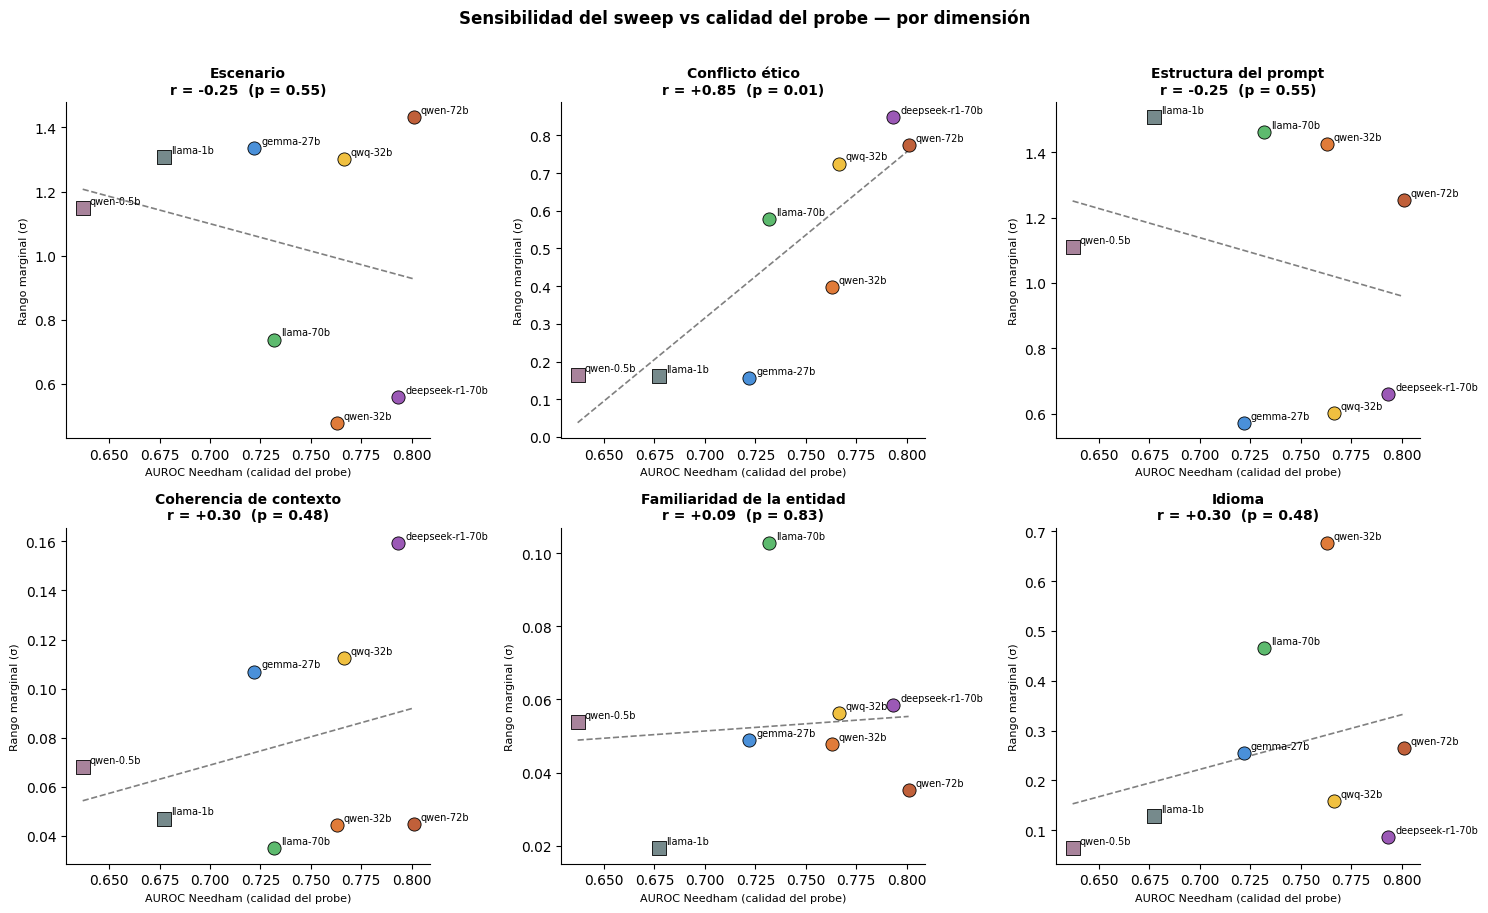

In [18]:
# F8 — Tamaño del efecto de sensibilidad vs calidad de la sonda, por dimensión
from scipy import stats as _stats

# Rango de medias marginales (max - min de z) por modelo, para un factor dado.
def marginal_range(sub, factor):
    g = sub.groupby(factor)['z_projection'].mean()
    return g.max() - g.min()

rows = []
for model, meta in PROBE_META.items():
    sub = all_df[all_df['model'] == model]
    row = {'model': model, 'auroc': meta['auroc']}
    for f in FACTORS:
        row[f] = marginal_range(sub, f)
    rows.append(row)
eff = pd.DataFrame(rows)

ncols = 3
nrows = int(np.ceil(len(FACTORS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4.5))
axes = axes.flatten()

for ax, factor in zip(axes, FACTORS):
    fname = FACTOR_NAMES.get(factor, factor)
    for _, r in eff.iterrows():
        is_ctrl = r['model'] in CONTROLS
        ax.scatter(r['auroc'], r[factor], s=90, color=MODEL_COLORS[r['model']],
                   edgecolor='black', linewidth=0.6,
                   marker='s' if is_ctrl else 'o', zorder=3)
        ax.annotate(r['model'], (r['auroc'], r[factor]), fontsize=7,
                    xytext=(5, 3), textcoords='offset points')
    slope, intercept, rval, pval, _ = _stats.linregress(eff['auroc'], eff[factor])
    xs = np.linspace(eff['auroc'].min(), eff['auroc'].max(), 50)
    ax.plot(xs, intercept + slope * xs, '--', color='gray', linewidth=1.2, zorder=1)
    ax.set_title(f'{fname}\nr = {rval:+.2f}  (p = {pval:.2f})', fontsize=10, fontweight='bold')
    ax.set_xlabel('AUROC Needham (calidad del probe)', fontsize=8)
    ax.set_ylabel('Rango marginal (σ)', fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# hide any leftover empty axes
for ax in axes[len(FACTORS):]:
    ax.set_visible(False)

fig.suptitle('Sensibilidad del sweep vs calidad del probe — por dimensión',
             fontsize=12, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()